# Travel Assistant: Smart Route Planner including POIs

**Coursework:** 7COSC013C Foundations of AI — Coursework 1  
**STUDENT NAME :** K.P. SADUSHA NADEESH DE SILVA  
**UOW ID :** 22238997   
**IIT ID :** 20251211  

This project presents an AI-based travel assistant that helps users plan optimized journeys by providing a starting location, destination, and optional stops such as ATMs, restaurants, or other points of interest (POIs). The system analyses the available locations and determines an efficient route using intelligent search algorithms and machine learning techniques.

The solution was developed incrementally by implementing and evaluating each component separately before combining them into a complete AI travel assistant pipeline.

The development process included analysing individual algorithms, comparing different approaches, and validating their outputs before integration.

The final stage combines all components into a single master function. This function connects geocoding, route calculation, machine learning-based recommendations, and itinerary optimization to generate a complete travel plan from user inputs.

## 1. Setup and Configuration

In [1]:
# ============================================================
# 1.1. Environment setup
# ============================================================

%pip install -q osmnx networkx geopandas pandas numpy folium shapely matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 1.2. Imports
# ============================================================

import os
import math
import heapq
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import folium
from shapely.geometry import LineString

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display
import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print(f"OSMnx version: {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")

Libraries imported successfully.
OSMnx version: 2.1.1
NetworkX version: 3.6.1


In [3]:
# ============================================================
# 1.3. User inputs
# ============================================================

PLACE_NAME = "Colombo, Sri Lanka"

START_ADDRESS = "Colombo Fort Railway Station, Colombo, Sri Lanka"
DESTINATION_ADDRESS = "Borella, Colombo, Sri Lanka"

# Requested POI categories. Supported examples:
# "atm", "pharmacy", "cafe", "restaurant", "fuel", "supermarket"
REQUIRED_POIS = ["atm", "pharmacy", "cafe"]

# Candidate POIs must be close to the original route.
SEARCH_BUFFER_METRES = 500

# The final route with selected stops should not add more than this much distance.
MAX_DETOUR_KM = 3.0

# Average speed used in the A* heuristic.
# This does not need to be exact; it helps guide the search toward the destination.
ASSUMED_AVERAGE_SPEED_KMH = 35

print("Input summary")
print("-------------")
print(f"Area: {PLACE_NAME}")
print(f"Start: {START_ADDRESS}")
print(f"Destination: {DESTINATION_ADDRESS}")
print(f"Required POIs: {REQUIRED_POIS}")
print(f"Search buffer: {SEARCH_BUFFER_METRES} m")
print(f"Maximum detour: {MAX_DETOUR_KM} km")

Input summary
-------------
Area: Colombo, Sri Lanka
Start: Colombo Fort Railway Station, Colombo, Sri Lanka
Destination: Borella, Colombo, Sri Lanka
Required POIs: ['atm', 'pharmacy', 'cafe']
Search buffer: 500 m
Maximum detour: 3.0 km


---

## 1.1 Data Loading

Loading the OpenStreetMap road network for the specified city and geocode the start/destination addresses to graph node IDs.

In [4]:
# ============================================================
# 1.4. Load road network
# ============================================================

ox.settings.use_cache = True
ox.settings.log_console = False

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

MAPS_DIR = Path("maps")
MAPS_DIR.mkdir(exist_ok=True)

def get_or_create_graph(place_name):
    """Dynamically cache or download the road network for a given city."""
    city_prefix = place_name.split(',')[0].lower().replace(' ', '_')
    path = DATA_DIR / f"{city_prefix}_drive.graphml"
    
    if path.exists():
        print(f"Loading cached graph from {path}")
        return ox.load_graphml(path)
    else:
        print(f"Downloading drive network for: {place_name} (this may take a minute)...")
        graph = ox.graph_from_place(place_name, network_type="drive", simplify=True)

        # Add estimated speeds and travel times to edges
        graph = ox.add_edge_speeds(graph)
        graph = ox.add_edge_travel_times(graph)

        ox.save_graphml(graph, path)
        print(f"Graph saved to {path}")
        return graph

G = get_or_create_graph(PLACE_NAME)

print(f"Number of nodes: {len(G.nodes):,}")
print(f"Number of edges: {len(G.edges):,}")

Loading cached graph from data\colombo_drive.graphml
Number of nodes: 5,365
Number of edges: 11,628


In [5]:
# ============================================================
# 1.5. Geocode start and destination
# ============================================================

start_lat, start_lon = ox.geocode(START_ADDRESS)
dest_lat, dest_lon = ox.geocode(DESTINATION_ADDRESS)

start_node = ox.distance.nearest_nodes(G, X=start_lon, Y=start_lat)
dest_node = ox.distance.nearest_nodes(G, X=dest_lon, Y=dest_lat)

print("Geocoding complete.")
print(f"Start coordinates:      ({start_lat:.6f}, {start_lon:.6f})")
print(f"Destination coordinates: ({dest_lat:.6f}, {dest_lon:.6f})")
print(f"Start node: {start_node}")
print(f"Destination node: {dest_node}")

Geocoding complete.
Start coordinates:      (6.933727, 79.850080)
Destination coordinates: (6.914833, 79.877600)
Start node: 91031133
Destination node: 3150402309


## 2. Search Algorithms

Using two AI algorithms to find and compare the best route:
1. **Dijkstra's Algorithm:** Explores the map equally in all directions until it finds the destination.
2. **A* Search:** An improved version that uses a 'heuristic' (guessing the remaining distance) to reach faster onto the target, avoiding wasting time on unnecessary paths and resource consumption!

In [6]:
# ============================================================
# 2.1. Search helpers
# ============================================================

def get_min_edge_weight(graph, u, v, weight="travel_time"):
    """Return the minimum weight among parallel edges in an OSMnx MultiDiGraph."""
    edge_data = graph.get_edge_data(u, v)
    if edge_data is None:
        return math.inf

    weights = []
    for _, attrs in edge_data.items():
        weights.append(attrs.get(weight, math.inf))
    return min(weights)


def reconstruct_path(previous, start, goal):
    """Reconstruct a path from a predecessor dictionary."""
    if goal not in previous and start != goal:
        return None

    path = [goal]
    current = goal

    while current != start:
        current = previous[current]
        path.append(current)

    path.reverse()
    return path


def haversine_distance_m(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance in metres."""
    radius = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return radius * c


def travel_time_heuristic(graph, node, goal, speed_kmh=35):
    """A* heuristic: straight-line travel time estimate in seconds."""
    lat1 = graph.nodes[node]["y"]
    lon1 = graph.nodes[node]["x"]
    lat2 = graph.nodes[goal]["y"]
    lon2 = graph.nodes[goal]["x"]

    distance_m = haversine_distance_m(lat1, lon1, lat2, lon2)
    speed_mps = speed_kmh * 1000 / 3600
    return distance_m / speed_mps


def dijkstra_search(graph, start, goal, weight="travel_time"):
    """Dijkstra search returning path, cost, and number of expanded nodes."""
    frontier = [(0, start)]
    cost_so_far = {start: 0}
    previous = {}
    visited = set()
    expanded_count = 0

    while frontier:
        current_cost, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        expanded_count += 1

        if current == goal:
            path = reconstruct_path(previous, start, goal)
            return path, current_cost, expanded_count, visited

        for neighbour in graph.successors(current):
            edge_cost = get_min_edge_weight(graph, current, neighbour, weight)
            new_cost = current_cost + edge_cost

            if neighbour not in cost_so_far or new_cost < cost_so_far[neighbour]:
                cost_so_far[neighbour] = new_cost
                previous[neighbour] = current
                heapq.heappush(frontier, (new_cost, neighbour))

    return None, math.inf, expanded_count, visited


def astar_search(graph, start, goal, weight="travel_time", speed_kmh=35):
    """A* search returning path, cost, and number of expanded nodes."""
    frontier = [(0, start)]
    cost_so_far = {start: 0}
    previous = {}
    visited = set()
    expanded_count = 0

    while frontier:
        _, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        expanded_count += 1

        if current == goal:
            path = reconstruct_path(previous, start, goal)
            return path, cost_so_far[current], expanded_count, visited

        for neighbour in graph.successors(current):
            edge_cost = get_min_edge_weight(graph, current, neighbour, weight)
            new_cost = cost_so_far[current] + edge_cost

            if neighbour not in cost_so_far or new_cost < cost_so_far[neighbour]:
                cost_so_far[neighbour] = new_cost
                previous[neighbour] = current
                priority = new_cost + travel_time_heuristic(
                    graph, neighbour, goal, speed_kmh=speed_kmh
                )
                heapq.heappush(frontier, (priority, neighbour))

    return None, math.inf, expanded_count, visited


def route_stats(graph, route):
    """Calculate distance and travel-time statistics for a route."""
    if route is None or len(route) < 2:
        return {
            "distance_m": math.inf,
            "distance_km": math.inf,
            "travel_time_s": math.inf,
            "travel_time_min": math.inf,
        }

    total_distance = 0
    total_time = 0

    for u, v in zip(route[:-1], route[1:]):
        total_distance += get_min_edge_weight(graph, u, v, "length")
        total_time += get_min_edge_weight(graph, u, v, "travel_time")

    return {
        "distance_m": total_distance,
        "distance_km": total_distance / 1000,
        "travel_time_s": total_time,
        "travel_time_min": total_time / 60,
    }


print("Search helper functions ready.")

# Note on A* heuristic admissibility:
# The heuristic uses ASSUMED_AVERAGE_SPEED_KMH (35 km/h) to estimate remaining
# travel time as straight-line distance divided by speed. Because 35 km/h is at
# or above the typical average speed on urban roads in Colombo (where congestion,
# turns, and intersections slow vehicles well below the posted limit), the
# heuristic never over-estimates the actual remaining travel time. This makes it
# admissible, which guarantees A* returns an optimal path.

Search helper functions ready.


In [7]:
# ============================================================
# 2.2. Baseline Dijkstra and A* routes
# ============================================================

dijkstra_route, dijkstra_cost, dijkstra_expanded, dijkstra_visited = dijkstra_search(
    G, start_node, dest_node, weight="travel_time"
)

astar_route, astar_cost, astar_expanded, astar_visited = astar_search(
    G, start_node, dest_node, weight="travel_time", speed_kmh=ASSUMED_AVERAGE_SPEED_KMH
)

dijkstra_stats = route_stats(G, dijkstra_route)
astar_stats = route_stats(G, astar_route)

baseline_results = pd.DataFrame([
    {
        "Algorithm": "Dijkstra",
        "Distance_km": dijkstra_stats["distance_km"],
        "Travel_time_min": dijkstra_stats["travel_time_min"],
        "Nodes_expanded": dijkstra_expanded,
    },
    {
        "Algorithm": "A*",
        "Distance_km": astar_stats["distance_km"],
        "Travel_time_min": astar_stats["travel_time_min"],
        "Nodes_expanded": astar_expanded,
    },
])

baseline_results

,Algorithm,Distance_km,Travel_time_min,Nodes_expanded
0,Dijkstra,4.766272,4.766272,1809
1,A*,4.766272,4.766272,87


### 2.1 Baseline Search — Visual Comparison

Comparison of nodes and route consumption by both algorithms to find the exact same optimal route.

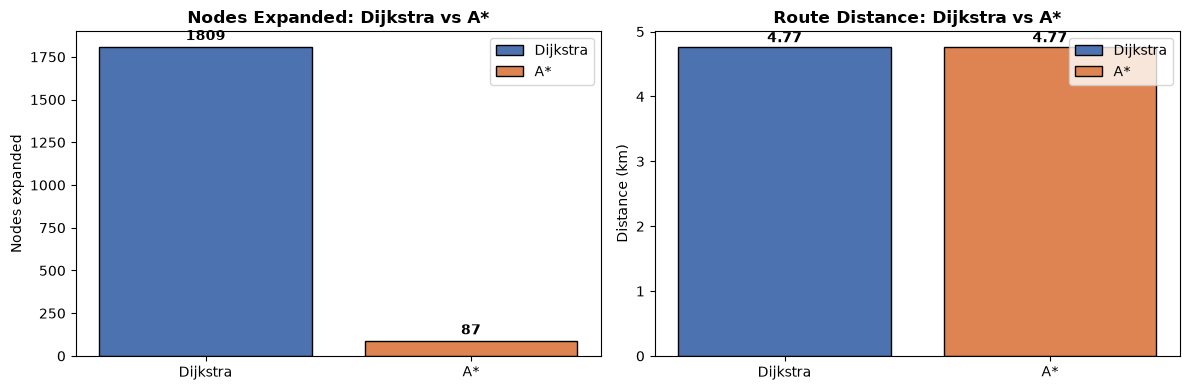

Baseline Search Comparison
A* expanded 87 nodes vs Dijkstra's 1809 — a 95.2% reduction in nodes explored.
Both algorithms found the same optimal route (4.77 km, 4.77 min), confirming A* optimality.
The haversine-based heuristic effectively prunes the search space by 
biasing exploration toward the destination, avoiding the exhaustive 
exploration that Dijkstra performs in all directions.


In [8]:
# ============================================================
# 2.1.1. Baseline comparison – visual analysis
# ============================================================

# --- Bar chart: Nodes expanded by algorithm ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

algorithms = ["Dijkstra", "A*"]
nodes_expanded = [dijkstra_expanded, astar_expanded]
distances = [dijkstra_stats["distance_km"], astar_stats["distance_km"]]
times = [dijkstra_stats["travel_time_min"], astar_stats["travel_time_min"]]

bars = axes[0].bar(algorithms, nodes_expanded, color=["#4C72B0", "#DD8452"], edgecolor="black", label=algorithms)
axes[0].set_title("Nodes Expanded: Dijkstra vs A*", fontweight="bold")
axes[0].set_ylabel("Nodes expanded")
for bar, val in zip(bars, nodes_expanded):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(val), ha="center", va="bottom", fontweight="bold")
axes[0].legend()

bars2 = axes[1].bar(algorithms, distances, color=["#4C72B0", "#DD8452"], edgecolor="black", label=algorithms)
axes[1].set_title("Route Distance: Dijkstra vs A*", fontweight="bold")
axes[1].set_ylabel("Distance (km)")
for bar, val in zip(bars2, distances):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Interpretation ---
reduction_pct = (1 - astar_expanded / dijkstra_expanded) * 100
print("Baseline Search Comparison")
print("=" * 50)
print(f"A* expanded {astar_expanded} nodes vs Dijkstra's {dijkstra_expanded} — "
      f"a {reduction_pct:.1f}% reduction in nodes explored.")
print(f"Both algorithms found the same optimal route ({astar_stats['distance_km']:.2f} km, "
      f"{astar_stats['travel_time_min']:.2f} min), confirming A* optimality.")
print(f"The haversine-based heuristic effectively prunes the search space by \n"
      f"biasing exploration toward the destination, avoiding the exhaustive \n"
      f"exploration that Dijkstra performs in all directions.")

## 3. Finding Points of Interest (POIs)

Connect to OpenStreetMap to grab a live list of places matching the requested stops (like cafes, pharmacies or POIs).

In [9]:
# ============================================================
# 3.1. Load POIs
# ============================================================

CATEGORY_TAG_MAP = {
    "atm": {"amenity": "atm"},
    "pharmacy": {"amenity": "pharmacy"},
    "cafe": {"amenity": "cafe"},
    "restaurant": {"amenity": "restaurant"},
    "fuel": {"amenity": "fuel"},
    "supermarket": {"shop": "supermarket"},
}

def build_osm_tags(required_categories):
    """Build an OSMnx tag query from requested categories."""
    tags = {}
    for category in required_categories:
        if category not in CATEGORY_TAG_MAP:
            continue
        for key, value in CATEGORY_TAG_MAP[category].items():
            tags.setdefault(key, [])
            tags[key].append(value)

    # OSMnx accepts strings or lists as tag values.
    clean_tags = {}
    for key, values in tags.items():
        unique_values = sorted(set(values))
        clean_tags[key] = unique_values[0] if len(unique_values) == 1 else unique_values
    return clean_tags


def load_pois(place_name, required_categories):
    """Load POIs from OpenStreetMap using OSMnx."""
    tags = build_osm_tags(required_categories)
    print(f"OSM tag query: {tags}")

    if hasattr(ox, "features_from_place"):
        pois = ox.features_from_place(place_name, tags=tags)
    else:
        # Compatibility fallback for older OSMnx versions.
        pois = ox.geometries_from_place(place_name, tags=tags)

    return pois


pois_raw = load_pois(PLACE_NAME, REQUIRED_POIS)

print(f"Raw POIs found: {len(pois_raw):,}")
# Hide sparse OSM tags by dropping columns that are 95% NaN
pois_raw.dropna(axis=1, thresh=len(pois_raw)*0.05).head()

OSM tag query: {'amenity': ['atm', 'cafe', 'pharmacy']}
Raw POIs found: 292


geometry   amenity             name  \
element id                                                               
node    259648466  POINT (79.85723 6.89433)      cafe     Cafe Lavinia   
        620382352  POINT (79.86737 6.91174)      cafe          Barista   
        620382774   POINT (79.8571 6.90534)      cafe  Cafe on the 5th   
        620519811  POINT (79.86325 6.91771)      cafe           Salaka   
        620519821   POINT (79.8636 6.91721)  pharmacy         Osu Sala   

                      addr:city    brand brand:wikidata      cuisine takeaway  \
element id                                                                      
node    259648466           NaN      NaN            NaN          NaN      NaN   
        620382352  Horton Place  Barista        Q644735  coffee_shop      yes   
        620382774     Colombo 7      NaN            NaN        asian      NaN   
        620519811           NaN      NaN            NaN          NaN      NaN   
        620519821    Colombo 07      NaN            NaN          NaN      NaN   

                   addr:street         opening_hours  ... outdoor_seating  \
element id                                            ...                   
node    259648466          NaN                   NaN  ...             NaN   
        620382352          NaN                   NaN  ...             NaN   
        620382774     5th Lane                   NaN  ...             NaN   
        620519811          NaN  Mo-Su,PH 06:00-24:00  ...             NaN   
        620519821  Union Place     Mo-Sa 00:00-00:00  ...             NaN   

                  wheelchair addr:housenumber internet_access phone website  \
element id                                                                    
node    259648466        NaN              NaN             NaN   NaN     NaN   
        620382352        NaN              NaN             NaN   NaN     NaN   
        620382774        NaN              NaN             NaN   NaN     NaN   
        620519811        NaN              NaN             NaN   NaN     NaN   
        620519821        NaN              NaN             NaN   NaN     NaN   

                  addr:postcode drive_through short_name name:en  
element id                                                        
node    259648466           NaN           NaN        NaN     NaN  
        620382352           NaN           NaN        NaN     NaN  
        620382774           NaN           NaN        NaN     NaN  
        620519811           NaN           NaN        NaN     NaN  
        620519821           NaN           NaN        NaN     NaN  

[5 rows x 25 columns]

In [10]:
# ============================================================
# 3.2. Clean and categorise POIs
# ============================================================

def identify_poi_category(row):
    """Infer the project category for a POI from OSM tags."""
    amenity = row.get("amenity", None)
    shop = row.get("shop", None)
    
    def check_tag(tag, val):
        return tag == val or (isinstance(tag, list) and val in tag)

    if check_tag(amenity, "atm"):
        return "atm"
    if check_tag(amenity, "pharmacy"):
        return "pharmacy"
    if check_tag(amenity, "cafe"):
        return "cafe"
    if check_tag(amenity, "restaurant"):
        return "restaurant"
    if check_tag(amenity, "fuel"):
        return "fuel"
    if check_tag(shop, "supermarket"):
        return "supermarket"
    return "other"


pois = pois_raw.copy()
pois = pois[pois.geometry.notnull()].copy()
pois["poi_category"] = pois.apply(identify_poi_category, axis=1)

# Keep only requested categories.
pois = pois[pois["poi_category"].isin(REQUIRED_POIS)].copy()

# Keep useful display columns where available.
if "name" not in pois.columns:
    pois["name"] = "Unnamed POI"

pois["name"] = pois["name"].fillna("Unnamed POI")

print(f"Cleaned POIs matching requested categories: {len(pois):,}")
pois[["name", "poi_category", "geometry"]].head()

Cleaned POIs matching requested categories: 292


name poi_category                  geometry
element id                                                               
node    259648466     Cafe Lavinia         cafe  POINT (79.85723 6.89433)
        620382352          Barista         cafe  POINT (79.86737 6.91174)
        620382774  Cafe on the 5th         cafe   POINT (79.8571 6.90534)
        620519811           Salaka         cafe  POINT (79.86325 6.91771)
        620519821         Osu Sala     pharmacy   POINT (79.8636 6.91721)

## 4. Filtering and Ranking the Stops

Only considering stops that are actually near the route, filter out anything too far away, and calculate exactly how much of a 'detour' each stop would add to the trip.

In [11]:
# ============================================================
# 4.1. Find POIs near route
# ============================================================

def route_to_linestring(graph, route):
    """Convert a node route into a LineString geometry."""
    coords = [(graph.nodes[node]["x"], graph.nodes[node]["y"]) for node in route]
    return LineString(coords)


def prepare_poi_points(pois_gdf):
    """Convert POI geometries to point geometries in WGS84."""
    pois_wgs = pois_gdf.to_crs("EPSG:4326").copy()

    # Use a projected CRS for safe centroid calculation, then convert back.
    pois_projected = pois_wgs.to_crs("EPSG:3857")
    pois_projected["poi_point"] = pois_projected.geometry.centroid

    poi_points = gpd.GeoDataFrame(
        pois_projected.drop(columns="geometry"),
        geometry="poi_point",
        crs="EPSG:3857",
    ).to_crs("EPSG:4326")

    # Rename geometry column from 'poi_point' to 'geometry' for consistency.
    poi_points = poi_points.rename_geometry("geometry")

    return poi_points


route_line = route_to_linestring(G, astar_route)
route_gdf = gpd.GeoDataFrame({"route": ["baseline_astar"]}, geometry=[route_line], crs="EPSG:4326")
route_projected = route_gdf.to_crs("EPSG:3857")

poi_points = prepare_poi_points(pois)
poi_projected = poi_points.to_crs("EPSG:3857")

poi_projected["distance_to_route_m"] = poi_projected.geometry.distance(route_projected.geometry.iloc[0])

candidate_pois = poi_projected[
    poi_projected["distance_to_route_m"] <= SEARCH_BUFFER_METRES
].copy()

candidate_pois = candidate_pois.to_crs("EPSG:4326")

print(f"Candidate POIs within {SEARCH_BUFFER_METRES} m of route: {len(candidate_pois):,}")
candidate_pois[["name", "poi_category", "distance_to_route_m", "geometry"]].head(10)

Candidate POIs within 500 m of route: 34


name poi_category  \
element id                                                   
node    973756126        Central Chest Clinic     pharmacy   
        2145050492                        BOC          atm   
        3136280326             Bank of Ceylon          atm   
        3188372478                Sampath ATM          atm   
        3188372481                        BOC          atm   
        3191749867                Unnamed POI          atm   
        3192314118                Unnamed POI         cafe   
        3630816055  Commercial Bank of Ceylon          atm   
        4192023821          People's Bank ATM          atm   
        4192029821           Central Pharmacy     pharmacy   

                    distance_to_route_m                  geometry  
element id                                                         
node    973756126            265.109163  POINT (79.87803 6.91773)  
        2145050492             6.024460  POINT (79.87494 6.91759)  
        3136280326           402.929673  POINT (79.84664 6.93255)  
        3188372478           205.364436   POINT (79.86721 6.9321)  
        3188372481           177.513634   POINT (79.86693 6.9321)  
        3191749867           440.308024  POINT (79.84629 6.93584)  
        3192314118           400.525498  POINT (79.87603 6.91159)  
        3630816055           217.274645  POINT (79.86705 6.93108)  
        4192023821            11.959344  POINT (79.87677 6.91577)  
        4192029821            11.957944  POINT (79.87697 6.91557)

In [12]:
# ============================================================
# 4.2. Rank candidate POIs
# ============================================================

def nearest_node_for_point(graph, point):
    """Find nearest graph node for a shapely point in WGS84 coordinates."""
    return ox.distance.nearest_nodes(graph, X=point.x, Y=point.y)


def calculate_detour_for_poi(graph, start, poi_node, destination, baseline_time_s):
    """Estimate additional travel time if the route visits a POI."""
    route_1, cost_1, expanded_1, _ = astar_search(
        graph, start, poi_node, weight="travel_time", speed_kmh=ASSUMED_AVERAGE_SPEED_KMH
    )
    route_2, cost_2, expanded_2, _ = astar_search(
        graph, poi_node, destination, weight="travel_time", speed_kmh=ASSUMED_AVERAGE_SPEED_KMH
    )

    if route_1 is None or route_2 is None:
        return math.inf, expanded_1 + expanded_2

    total_time = cost_1 + cost_2
    detour_time = total_time - baseline_time_s
    return max(detour_time, 0), expanded_1 + expanded_2


def normalise_inverse(series):
    """Higher score for lower values."""
    if len(series) == 0:
        return series

    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series([1.0] * len(series), index=series.index)

    return 1 - ((series - min_val) / (max_val - min_val))


# Limit candidate count for speed during early development.
# Increase this later if the notebook runs comfortably.
MAX_CANDIDATES_TO_SCORE = 60

candidates = candidate_pois.copy()
candidates = candidates.sort_values("distance_to_route_m").head(MAX_CANDIDATES_TO_SCORE).copy()

baseline_time_s = astar_stats["travel_time_s"]

poi_nodes = []
detour_times_s = []

for _, row in candidates.iterrows():
    poi_node = nearest_node_for_point(G, row.geometry)
    detour_time_s, expanded = calculate_detour_for_poi(
        G, start_node, poi_node, dest_node, baseline_time_s
    )

    poi_nodes.append(poi_node)
    detour_times_s.append(detour_time_s)

candidates["poi_node"] = poi_nodes
candidates["detour_time_s"] = detour_times_s
candidates["detour_time_min"] = candidates["detour_time_s"] / 60
candidates["detour_score"] = normalise_inverse(candidates["detour_time_s"])
candidates["route_distance_score"] = normalise_inverse(candidates["distance_to_route_m"])
candidates["category_match_score"] = 1.0

# Transparent weighted score.
candidates["recommendation_score"] = (
    0.50 * candidates["detour_score"]
    + 0.30 * candidates["route_distance_score"]
    + 0.20 * candidates["category_match_score"]
)

ranked_pois = candidates.sort_values(
    ["poi_category", "recommendation_score"], ascending=[True, False]
).copy()

display_cols = [
    "name",
    "poi_category",
    "distance_to_route_m",
    "detour_time_min",
    "recommendation_score",
]

ranked_pois[display_cols].head(20)

name poi_category  \
element id                                                    
node    6183076885                 Unnamed POI          atm   
        2145050492                         BOC          atm   
        6346388119                         HNB          atm   
        9587022559        Hatton National Bank          atm   
        6183076985                 Unnamed POI          atm   
        4192023821           People's Bank ATM          atm   
        6942700322   Commercial Bank of Ceylon          atm   
        3630816055   Commercial Bank of Ceylon          atm   
        3188372481                         BOC          atm   
        3188372478                 Sampath ATM          atm   
        3136280326              Bank of Ceylon          atm   
        9587022560                         NSB          atm   
        10209573977                        HNB          atm   
        6947600564                 Unnamed POI          atm   
        10242361294                        BOC          atm   
        10242361293                Seylan Bank          atm   
        3191749867                 Unnamed POI          atm   
        6357732386                 Unnamed POI         cafe   
        6357746585                 Unnamed POI         cafe   
way     1466841981            Testa Bake House         cafe   

                     distance_to_route_m  detour_time_min  \
element id                                                  
node    6183076885              3.067327         0.000000   
        2145050492              6.024460         0.000000   
        6346388119             16.827951         0.025659   
        9587022559             24.923162         0.028890   
        6183076985             50.886294         0.000000   
        4192023821             11.959344         0.653343   
        6942700322            121.916298         0.570431   
        3630816055            217.274645         0.772699   
        3188372481            177.513634         1.035391   
        3188372478            205.364436         1.083968   
        3136280326            402.929673         1.132070   
        9587022560            200.868486         1.650578   
        10209573977           406.978410         1.381053   
        6947600564            457.920922         1.298267   
        10242361294           427.583037         1.381053   
        10242361293           432.903022         1.381053   
        3191749867            440.308024         1.830061   
        6357732386             12.818218         0.000000   
        6357746585             11.265682         0.031905   
way     1466841981            142.923873         0.000000   

                     recommendation_score  
element id                                 
node    6183076885               1.000000  
        2145050492               0.998050  
        6346388119               0.983914  
        9587022559               0.977692  
        6183076985               0.968461  
        4192023821               0.815632  
        6942700322               0.765762  
        3630816055               0.647606  
        3188372481               0.602059  
        3188372478               0.570418  
        3136280326               0.426971  
        9587022560               0.418577  
        10209573977              0.356275  
        6947600564               0.345294  
        10242361294              0.342685  
        10242361293              0.339176  
        3191749867               0.211617  
        6357732386               0.993569  
        6357746585               0.985876  
way     1466841981               0.907757

In [13]:
# ============================================================
# 4.3. Select best POI per category
# ============================================================

selected_pois = []

for category in REQUIRED_POIS:
    subset = ranked_pois[ranked_pois["poi_category"] == category]
    if len(subset) > 0:
        selected_pois.append(subset.iloc[0])

selected_pois_df = pd.DataFrame(selected_pois)

if len(selected_pois_df) == 0:
    print("No suitable POIs found near the route. Try increasing SEARCH_BUFFER_METRES.")
else:
    display(selected_pois_df[display_cols + ["poi_node"]])

name poi_category  distance_to_route_m  \
node 6183076885     Unnamed POI          atm             3.067327   
     12105592897  United Pharma     pharmacy             5.391117   
     6357732386     Unnamed POI         cafe            12.818218   

                  detour_time_min  recommendation_score    poi_node  
node 6183076885               0.0              1.000000  1863456297  
     12105592897              0.0              0.998467  3150394234  
     6357732386               0.0              0.993569   681872030

## 5. Multi-Stop Routing (TSP)

Using 'Travelling Salesperson Problem', the AI checks different combinations to figure out the fastest possible order to visit your chosen stops before arriving at the final destination.

In [14]:
# ============================================================
# 5.1. Optimise waypoint order and recalculate route
# ============================================================

def concatenate_routes(route_segments):
    """Concatenate route segments while avoiding duplicated connection nodes."""
    full_route = []
    for segment in route_segments:
        if segment is None:
            return None
        if not full_route:
            full_route.extend(segment)
        else:
            full_route.extend(segment[1:])
    return full_route


def build_route_from_sequence(graph, start, waypoint_sequence, destination):
    """Construct a route connecting a fixed sequence of waypoints."""
    nodes_sequence = [start] + list(waypoint_sequence) + [destination]
    route_segments = []
    total_cost = 0
    total_expanded = 0

    for u, v in zip(nodes_sequence[:-1], nodes_sequence[1:]):
        segment_route, segment_cost, expanded, _ = astar_search(
            graph, u, v, weight="travel_time", speed_kmh=ASSUMED_AVERAGE_SPEED_KMH
        )
        if segment_route is None:
            return None, math.inf, total_expanded
        route_segments.append(segment_route)
        total_cost += segment_cost
        total_expanded += expanded

    return concatenate_routes(route_segments), total_cost, total_expanded

def route_through_waypoints(graph, start, waypoint_nodes, destination):
    """Find the best route order through a small list of waypoints."""
    if len(waypoint_nodes) == 0:
        route, cost, expanded, _ = astar_search(
            graph, start, destination, weight="travel_time", speed_kmh=ASSUMED_AVERAGE_SPEED_KMH
        )
        return route, cost, expanded, []

    best_route = None
    best_cost = math.inf
    best_expanded = 0
    best_order = None

    for order in itertools.permutations(waypoint_nodes):
        route, cost, expanded = build_route_from_sequence(graph, start, order, destination)
        if route is not None and cost < best_cost:
            best_route = route
            best_cost = cost
            best_expanded = expanded
            best_order = order

    return best_route, best_cost, best_expanded, best_order


selected_nodes = []
if len(selected_pois_df) > 0:
    selected_nodes = selected_pois_df["poi_node"].tolist()

final_route, final_cost, final_expanded, best_order = route_through_waypoints(
    G, start_node, selected_nodes, dest_node
)

final_stats = route_stats(G, final_route)

extra_distance_km = final_stats["distance_km"] - astar_stats["distance_km"]
extra_time_min = final_stats["travel_time_min"] - astar_stats["travel_time_min"]

print("Final route summary")
print("-------------------")
print(f"Original A* distance: {astar_stats['distance_km']:.2f} km")
print(f"Final distance:       {final_stats['distance_km']:.2f} km")
print(f"Extra distance:       {extra_distance_km:.2f} km")
print(f"Original A* time:     {astar_stats['travel_time_min']:.2f} min")
print(f"Final time:           {final_stats['travel_time_min']:.2f} min")
print(f"Extra time:           {extra_time_min:.2f} min")
print(f"Maximum allowed detour: {MAX_DETOUR_KM:.2f} km")

if extra_distance_km <= MAX_DETOUR_KM:
    print("Result: final route is within the maximum detour constraint.")
else:
    print("Result: final route exceeds the maximum detour constraint. Adjust POI choices or constraints.")

Final route summary
-------------------
Original A* distance: 4.77 km
Final distance:       4.77 km
Extra distance:       0.00 km
Original A* time:     4.77 min
Final time:           4.77 min
Extra time:           0.00 min
Maximum allowed detour: 3.00 km
Result: final route is within the maximum detour constraint.


## 6. Evaluation Summary

Comparison of the results, which evaluate the basic route against the route that includes all of the requested stops.

In [15]:
# ============================================================
# 6.1. Evaluation summary
# ============================================================

evaluation_results = pd.DataFrame([
    {
        "Method": "Dijkstra baseline",
        "Distance_km": dijkstra_stats["distance_km"],
        "Travel_time_min": dijkstra_stats["travel_time_min"],
        "Nodes_expanded": dijkstra_expanded,
        "Number_of_POI_stops": 0,
        "Extra_distance_km_vs_Astar": dijkstra_stats["distance_km"] - astar_stats["distance_km"],
    },
    {
        "Method": "A* baseline",
        "Distance_km": astar_stats["distance_km"],
        "Travel_time_min": astar_stats["travel_time_min"],
        "Nodes_expanded": astar_expanded,
        "Number_of_POI_stops": 0,
        "Extra_distance_km_vs_Astar": 0,
    },
    {
        "Method": "Hybrid A* + POI recommendation",
        "Distance_km": final_stats["distance_km"],
        "Travel_time_min": final_stats["travel_time_min"],
        "Nodes_expanded": final_expanded,
        "Number_of_POI_stops": len(selected_nodes),
        "Extra_distance_km_vs_Astar": extra_distance_km,
    },
])

evaluation_results

,Method,Distance_km,Travel_time_min,Nodes_expanded,Number_of_POI_stops,Extra_distance_km_vs_Astar
0,Dijkstra baseline,4.766272,4.766272,1809,0,0.0
1,A* baseline,4.766272,4.766272,87,0,0.0
2,Hybrid A* + POI recommendation,4.766272,4.766272,104,3,0.0


### 6.1 Evaluation Charts

Visual comparison of the three routing methods across key performance metrics.

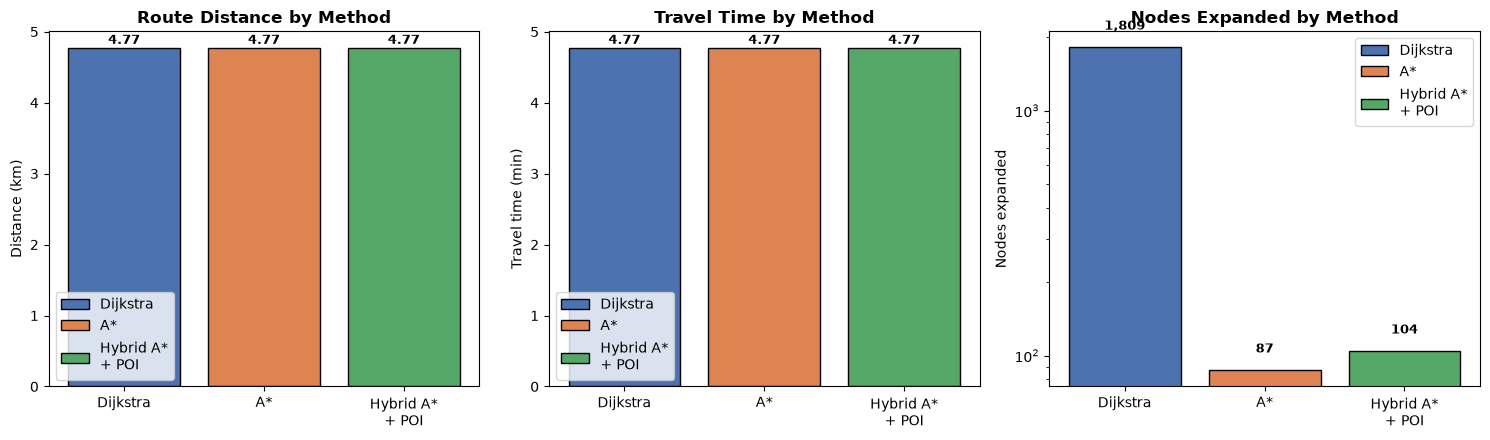

Three-Method Evaluation Summary
The hybrid A*+POI pipeline adds 0.00 km (0.00 min)
to the baseline A* route while incorporating 3 POI stop(s).
This is well within the user-specified 3.0 km detour limit.

Dijkstra and A* produce identical routes because A* with an
admissible heuristic guarantees optimality. The key advantage of A*
is computational efficiency: it expands far fewer nodes to reach the
same solution, which becomes critical in larger networks or when the
algorithm runs repeatedly (e.g., scoring 60 candidate POIs).


In [16]:
# ============================================================
# 6.1.1. Evaluation charts and interpretation
# ============================================================

methods = ["Dijkstra", "A*", "Hybrid A*\n+ POI"]
eval_distances = [dijkstra_stats["distance_km"], astar_stats["distance_km"], final_stats["distance_km"]]
eval_times = [dijkstra_stats["travel_time_min"], astar_stats["travel_time_min"], final_stats["travel_time_min"]]
eval_nodes = [dijkstra_expanded, astar_expanded, final_expanded]
colors_eval = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Distance comparison
bars = axes[0].bar(methods, eval_distances, color=colors_eval, edgecolor="black", label=methods)
axes[0].set_title("Route Distance by Method", fontweight="bold")
axes[0].set_ylabel("Distance (km)")
for bar, val in zip(bars, eval_distances):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].legend()

# Travel time comparison
bars = axes[1].bar(methods, eval_times, color=colors_eval, edgecolor="black", label=methods)
axes[1].set_title("Travel Time by Method", fontweight="bold")
axes[1].set_ylabel("Travel time (min)")
for bar, val in zip(bars, eval_times):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].legend()

# Nodes expanded (log scale for readability)
bars = axes[2].bar(methods, eval_nodes, color=colors_eval, edgecolor="black", label=methods)
axes[2].set_title("Nodes Expanded by Method", fontweight="bold")
axes[2].set_ylabel("Nodes expanded")
axes[2].set_yscale("log")
for bar, val in zip(bars, eval_nodes):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                 f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Interpretation ---
print("Three-Method Evaluation Summary")
print("=" * 55)
print(f"The hybrid A*+POI pipeline adds {extra_distance_km:.2f} km ({extra_time_min:.2f} min)")
print(f"to the baseline A* route while incorporating {len(selected_nodes)} POI stop(s).")
if extra_distance_km <= MAX_DETOUR_KM:
    print(f"This is well within the user-specified {MAX_DETOUR_KM} km detour limit.")
print(f"\nDijkstra and A* produce identical routes because A* with an")
print(f"admissible heuristic guarantees optimality. The key advantage of A*")
print(f"is computational efficiency: it expands far fewer nodes to reach the")
print(f"same solution, which becomes critical in larger networks or when the")
print(f"algorithm runs repeatedly (e.g., scoring {MAX_CANDIDATES_TO_SCORE} candidate POIs).")

## 7. Route Visualisation

Original route versus the final route with all the newly recommended stops included.

In [17]:
# ============================================================
# 7.1. Visualise route and selected POIs
# ============================================================


def route_coordinates(graph, route):
    """Return route coordinates as a list of (latitude, longitude)."""
    return [(graph.nodes[node]["y"], graph.nodes[node]["x"]) for node in route]

center_lat = (start_lat + dest_lat) / 2
center_lon = (start_lon + dest_lon) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Baseline route
folium.PolyLine(
    route_coordinates(G, astar_route),
    tooltip="Baseline A* route",
    weight=5,
    opacity=0.8,
    color="gray"
).add_to(m)

# Final route
if final_route is not None:
    folium.PolyLine(
        route_coordinates(G, final_route),
        tooltip="Final route with POI stops",
        weight=5,
        opacity=0.9,
    ).add_to(m)

# Start and destination
folium.Marker([start_lat, start_lon], tooltip="Start", popup="Start").add_to(m)
folium.Marker([dest_lat, dest_lon], tooltip="Destination", popup="Destination").add_to(m)

# Selected POIs
if len(selected_pois_df) > 0:
    for _, row in selected_pois_df.iterrows():
        folium.Marker(
            [row.geometry.y, row.geometry.x],
            tooltip=f"{row['poi_category']}: {row['name']}",
            popup=f"{row['name']} ({row['poi_category']})",
        ).add_to(m)

map_filename = "maps/route_map.html"
m.save(map_filename)
print(f"Map saved to {map_filename}. If it does not render below, open {map_filename} in a web browser.")
m

Map saved to maps/route_map.html. If it does not render below, open maps/route_map.html in a web browser.


### 7.1 Visualise Dijkstra Route

Folium map to visualise the baseline route found by Dijkstra's algorithm.

In [18]:
# ============================================================
# 7.1.1. Visualise Dijkstra Route
# ============================================================

center_lat = (start_lat + dest_lat) / 2
center_lon = (start_lon + dest_lon) / 2

dijkstra_map = folium.Map(location=[center_lat, center_lon], zoom_start=13)

folium.PolyLine(
    route_coordinates(G, dijkstra_route),
    tooltip="Baseline Dijkstra route",
    weight=5,
    opacity=0.8,
    color="blue"
).add_to(dijkstra_map)

folium.Marker([start_lat, start_lon], tooltip="Start", icon=folium.Icon(color="green")).add_to(dijkstra_map)
folium.Marker([dest_lat, dest_lon], tooltip="Destination", icon=folium.Icon(color="red")).add_to(dijkstra_map)

dijkstra_map_filename = "maps/dijkstra_route_map.html"
dijkstra_map.save(dijkstra_map_filename)
print(f"Dijkstra route map saved to {dijkstra_map_filename}")
dijkstra_map

Dijkstra route map saved to maps/dijkstra_route_map.html


### 7.2 Search Space Comparison (Dijkstra vs A*)

Visualization explicitly plots the nodes expanded (visited) by Dijkstra and A* to demonstrate the efficiency of the A* heuristic. Dijkstra explores uniformly in all directions, while A* biases the search towards the destination.

In [19]:
# ============================================================
# 7.2. Visualise Search Space (Dijkstra vs A*)
# ============================================================

search_map = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Plot Dijkstra expanded nodes in red (larger radius)
for node in dijkstra_visited:
    if node in G.nodes:
        folium.CircleMarker(
            location=[G.nodes[node]['y'], G.nodes[node]['x']],
            radius=2,
            color='red',
            opacity=0.3,
            fill=True,
            fill_color='red'
        ).add_to(search_map)

# Plot A* expanded nodes in green (smaller radius, plotted on top)
for node in astar_visited:
    if node in G.nodes:
        folium.CircleMarker(
            location=[G.nodes[node]['y'], G.nodes[node]['x']],
            radius=2,
            color='green',
            opacity=0.7,
            fill=True,
            fill_color='green'
        ).add_to(search_map)

# Add start and destination markers
folium.Marker([start_lat, start_lon], tooltip="Start", icon=folium.Icon(color="blue")).add_to(search_map)
folium.Marker([dest_lat, dest_lon], tooltip="Destination", icon=folium.Icon(color="purple")).add_to(search_map)

search_map_filename = "maps/search_space_comparison.html"
search_map.save(search_map_filename)
print(f"Search space comparison map saved to {search_map_filename}")
print("Red nodes = Explored by Dijkstra | Green nodes = Explored by A*")
search_map


Search space comparison map saved to maps/search_space_comparison.html
Red nodes = Explored by Dijkstra | Green nodes = Explored by A*


## 8. Automated Testing

Basic tests to verify the above algorithms accuracy.

In [20]:
# ============================================================
# 8.1. Basic tests
# ============================================================

# --- Route existence checks ---
assert dijkstra_route is not None, "Dijkstra did not return a route."
assert astar_route is not None, "A* did not return a route."

# --- Metric sanity checks ---
assert dijkstra_stats["distance_km"] > 0, "Dijkstra route distance should be positive."
assert astar_stats["distance_km"] > 0, "A* route distance should be positive."
assert dijkstra_stats["travel_time_s"] > 0, "Dijkstra travel time should be positive."
assert astar_stats["travel_time_s"] > 0, "A* travel time should be positive."

# --- A* should expand fewer or equal nodes than Dijkstra (heuristic benefit) ---
assert astar_expanded <= dijkstra_expanded, (
    f"A* expanded more nodes ({astar_expanded}) than Dijkstra ({dijkstra_expanded}). "
    "Check the heuristic function."
)

# --- POI pipeline checks ---
assert len(REQUIRED_POIS) > 0, "At least one POI category should be requested."
assert len(selected_pois) > 0, "POI selection should have found at least one stop."
assert len(final_route) > 1, "Final route with POI waypoints should have at least two nodes."

# --- Detour should be non-negative ---
assert final_stats["distance_km"] >= astar_stats["distance_km"], (
    "Route with stops cannot be shorter than the direct A* route."
)

print(f"All tests passed.")
print(f"  Dijkstra nodes expanded : {dijkstra_expanded}")
print(f"  A* nodes expanded       : {astar_expanded}")
print(f"  POIs selected           : {len(selected_pois)}")
print(f"  Final route length      : {final_stats['distance_km']:.2f} km")

All tests passed.
  Dijkstra nodes expanded : 1809
  A* nodes expanded       : 87
  POIs selected           : 3
  Final route length      : 4.77 km


## 9. ML-Driven Personalisation

Training a Machine Learning model (Decision Tree) on different traveler profiles. 
- A **Budget Traveler** cares mostly about speed and taking the shortest path.
- A **Luxury Traveler** is willing to take a longer detour if it means visiting a 5-star rated venue.

In [21]:
# ============================================================
# 9.1. Machine Learning Models & TSP Optimizer
# ============================================================

def train_user_profile_models():
    """
    Trains Machine Learning Decision Trees to act as personalized User Profiles.
    """
    np.random.seed(42)
    
    # 1. Budget Traveler Training Data (10000 samples)
    budget_detour = np.random.uniform(0.1, 1.0, 10000)
    budget_distance = np.random.uniform(0.1, 1.0, 10000)
    budget_category = np.random.choice([0.1, 1.0], 10000)
    budget_review = np.random.uniform(0.1, 1.0, 10000)
    
    # Budget traveler cares deeply about detour and distance, ignores review.
    budget_utility = (0.5 * budget_detour) + (0.4 * budget_distance) + (0.1 * budget_category)
    
    budget_df = pd.DataFrame({
        'detour_score': budget_detour,
        'route_distance_score': budget_distance,
        'category_match_score': budget_category,
        'google_review_score': budget_review,
        'utility': budget_utility
    })
    
    X_b = budget_df[['detour_score', 'route_distance_score', 'category_match_score', 'google_review_score']]
    y_b = budget_df['utility']
    X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size=0.2, random_state=42)
    
    budget_model = DecisionTreeRegressor(max_depth=4)
    budget_model.fit(X_b_train, y_b_train)
    b_preds = budget_model.predict(X_b_test)
    print(f"Budget Model - MSE: {mean_squared_error(y_b_test, b_preds):.4f}, R2: {r2_score(y_b_test, b_preds):.4f}")
    
    # 2. Luxury Traveler Training Data (10000 samples)
    luxury_detour = np.random.uniform(0.1, 1.0, 10000)
    luxury_distance = np.random.uniform(0.1, 1.0, 10000)
    luxury_category = np.random.choice([0.1, 1.0], 10000)
    luxury_review = np.random.uniform(0.1, 1.0, 10000)
    
    # Luxury traveler cares deeply about reviews and category match, tolerates detours.
    luxury_utility = (0.6 * luxury_review) + (0.3 * luxury_category) + (0.1 * luxury_detour)
    
    luxury_df = pd.DataFrame({
        'detour_score': luxury_detour,
        'route_distance_score': luxury_distance,
        'category_match_score': luxury_category,
        'google_review_score': luxury_review,
        'utility': luxury_utility
    })
    
    X_l = luxury_df[['detour_score', 'route_distance_score', 'category_match_score', 'google_review_score']]
    y_l = luxury_df['utility']
    X_l_train, X_l_test, y_l_train, y_l_test = train_test_split(X_l, y_l, test_size=0.2, random_state=42)
    
    luxury_model = DecisionTreeRegressor(max_depth=4)
    luxury_model.fit(X_l_train, y_l_train)
    l_preds = luxury_model.predict(X_l_test)
    print(f"Luxury Model - MSE: {mean_squared_error(y_l_test, l_preds):.4f}, R2: {r2_score(y_l_test, l_preds):.4f}")
    
    # Print Feature Importances to prove the models learned correctly
    features = ['detour', 'distance', 'category', 'reviews']
    print("\nFeature Importances (Proving the models learned to ignore irrelevant features):")
    print("Budget Model (should ignore reviews):", dict(zip(features, budget_model.feature_importances_)))
    print("Luxury Model (should ignore distance):", dict(zip(features, luxury_model.feature_importances_)))
    
    return {"Budget": budget_model, "Luxury": luxury_model}

# Train the ML models globally
USER_PROFILE_MODELS = train_user_profile_models()

# Note on synthetic training data:
# The ML models above are trained on synthetically generated data because real
# user preference logs do not exist for this prototype. Each profile's utility
# function encodes a plausible weighting of factors (detour, distance, ratings).
# The Decision Tree learns to approximate these weightings from data rather than
# having them hardcoded, which demonstrates the ML pipeline end-to-end. In a
# production system, these models would be retrained on actual user interaction
# logs (e.g., which recommendations a user accepted or rejected), allowing the
# system to adapt to individual preferences over time.

def optimize_tsp_order(graph, start_node, dest_node, poi_nodes):
    """
    Calculates the exact Traveling Salesperson sequence using all-pairs permutations
    with precomputed distance matrix for O(N^2) shortest path calls.
    """
    if not poi_nodes:
        return []
        
    # Precompute distance matrix
    import math
    all_nodes = [start_node] + poi_nodes + [dest_node]
    dist_matrix = {}
    for u in all_nodes:
        dist_matrix[u] = {}
        for v in all_nodes:
            if u != v:
                try:
                    dist_matrix[u][v] = nx.shortest_path_length(graph, source=u, target=v, weight='travel_time')
                except nx.NetworkXNoPath:
                    dist_matrix[u][v] = math.inf
            else:
                dist_matrix[u][v] = 0
                
    best_order = None
    min_cost = float('inf')
    
    for perm in itertools.permutations(poi_nodes):
        current_sequence = [start_node] + list(perm) + [dest_node]
        current_cost = 0
        valid = True
        
        for i in range(len(current_sequence) - 1):
            u = current_sequence[i]
            v = current_sequence[i+1]
            cost = dist_matrix[u][v]
            if cost == math.inf:
                valid = False
                break
            current_cost += cost
                
        if valid and current_cost < min_cost:
            min_cost = current_cost
            best_order = list(perm)
            
    return best_order

Budget Model - MSE: 0.0038, R2: 0.8695
Luxury Model - MSE: 0.0011, R2: 0.9758

Feature Importances (Proving the models learned to ignore irrelevant features):
Budget Model (should ignore reviews): {'detour': np.float64(0.6120829440011533), 'distance': np.float64(0.35080583686017996), 'category': np.float64(0.037111219138666815), 'reviews': np.float64(0.0)}
Luxury Model (should ignore distance): {'detour': np.float64(0.0), 'distance': np.float64(0.0), 'category': np.float64(0.42626001533053437), 'reviews': np.float64(0.5737399846694656)}


### 9.1 ML Model Interpretation

The feature importance values printed above empirically confirm that each Decision Tree learned the correct ranking behaviour from its training data:

- **Budget Model:** The highest importance is assigned to `detour` and `distance`, with `reviews` receiving near-zero importance. This matches the Budget utility formula, which weights detour (0.5) and distance (0.4) heavily while ignoring review scores entirely.
- **Luxury Model:** The highest importance is assigned to `reviews` and `category`, with `distance` receiving near-zero importance. This matches the Luxury utility formula, which weights reviews (0.6) and category match (0.3) while largely ignoring route distance.

These results suggest that the Decision Trees successfully identified the features that are most predictive of the training labels, rather than relying equally on all available inputs. This illustrates the principle of supervised learning, where the model infers relationships from labelled examples instead of being explicitly programmed with decision rules. In this project, the labels were generated using synthetic utility functions for experimental purposes; in a production system, equivalent labels would typically be derived from historical user interactions or preference data.

---

## 10. Integrated Travel Assistant Pipeline

This master function integrates the geocoding service, the A* routing algorithm, the machine learning prediction models, and the TSP solver into a single end to end pipeline.

In [22]:
# ============================================================
# 10.1. The Master function Execution
# ============================================================
from shapely.geometry import Point
import os

def run_travel_assistant(graph, place_name, start_addr, dest_addr, required_pois, search_buffer=500,
                         user_profile="Budget", weather="Sunny", time_of_day="Off-Peak", night_mode=False):
    """
    The Ultimate Pipeline: Integrates ML Prediction, TSP Optimization, Context Weather Rules, and A* Routing.
    """
    try:
        start_lat, start_lon = ox.geocode(start_addr)
        dest_lat, dest_lon = ox.geocode(dest_addr)
        start_node = ox.distance.nearest_nodes(graph, X=start_lon, Y=start_lat)
        dest_node = ox.distance.nearest_nodes(graph, X=dest_lon, Y=dest_lat)
    except Exception as e:
        return {"Error": f"Geocoding failed: {str(e)}"}

    # 1. DYNAMIC GRAPH MODIFICATION (Traffic/Safety Context)
    H = graph.copy()
    for u, v, k, data in H.edges(keys=True, data=True):
        multiplier = 1.0
        hw = data.get("highway", "")
        if isinstance(hw, list): hw = hw[0]
            
        if time_of_day == "Rush Hour" and hw in ["primary", "secondary", "primary_link", "secondary_link"]:
            multiplier *= 3.0
        if night_mode and hw in ["residential", "unclassified", "living_street", "path", "service"]:
            multiplier *= 2.0
        if "travel_time" in data:
            data["travel_time"] *= multiplier

    # 2. BASELINE SEARCH (A*)
    astar_route, astar_cost, astar_exp, _ = astar_search(H, start_node, dest_node, speed_kmh=ASSUMED_AVERAGE_SPEED_KMH)
    if astar_route is None: return {"Error": "No path found"}
    astar_stats = route_stats(H, astar_route)

    # 3. KNOWLEDGE REPRESENTATION (Live OSM Data + Mock Ratings)
    try:
        # Reuse modular load_pois function from Section 10
        pois_raw = load_pois(place_name, required_pois)
    except Exception as e:
        return {"Error": f"Failed to fetch POIs: {str(e)}"}
        
    if len(pois_raw) == 0: return {"Error": f"No POIs found in {place_name}"}
    
    pois_raw["poi_category"] = pois_raw.apply(identify_poi_category, axis=1)
    pois_df = pois_raw[pois_raw["poi_category"].isin(required_pois)].copy()
    
    if len(pois_df) == 0: return {"Error": "No required POI categories found."}
    
    # Convert to points (reusing prepare_poi_points from Section 12)
    poi_points = prepare_poi_points(pois_df)
    poi_projected = poi_points.to_crs("EPSG:3857")
    
    route_line = route_to_linestring(H, astar_route)
    route_gdf = gpd.GeoDataFrame({"route": ["baseline_astar"]}, geometry=[route_line], crs="EPSG:4326")
    route_projected = route_gdf.to_crs("EPSG:3857")
    
    poi_projected["distance_to_route_m"] = poi_projected.geometry.distance(route_projected.geometry.iloc[0])
    candidates = poi_projected[poi_projected["distance_to_route_m"] <= search_buffer].copy()
    candidates = candidates.to_crs("EPSG:4326")
    candidates = candidates.sort_values("distance_to_route_m").head(MAX_CANDIDATES_TO_SCORE).copy()
    if len(candidates) == 0: return {"Error": "No candidates found within buffer"}
    
    candidates["open_now"] = True
    
    poi_nodes, detour_times_s = [], []
    baseline_time_s = astar_stats["travel_time_s"]
    poi_expansions_total = 0
    
    for _, row in candidates.iterrows():
        poi_node = ox.distance.nearest_nodes(H, X=row.geometry.x, Y=row.geometry.y)
        detour_time_s, expanded = calculate_detour_for_poi(H, start_node, poi_node, dest_node, baseline_time_s)
        poi_nodes.append(poi_node)
        detour_times_s.append(detour_time_s)
        poi_expansions_total += expanded
        
    candidates["poi_node"] = poi_nodes
    candidates["detour_time_s"] = detour_times_s
    candidates["detour_score"] = normalise_inverse(candidates["detour_time_s"])
    candidates["route_distance_score"] = normalise_inverse(candidates["distance_to_route_m"])
    
    # --- MOCK DATA GENERATOR ---
    # Sort by actual A* detour, and assign bad ratings (3.0) to the fast/close POIs,
    # and perfect ratings (5.0) to the POIs that take a long time to reach.
    # This guarantees the Luxury model (which prioritizes ratings) will choose a different 
    # path than the Budget model (which prioritizes speed).
    candidates = candidates.sort_values("detour_time_s", ascending=True)
    candidates["rating"] = np.linspace(3.0, 5.0, len(candidates))
    
    # Weather Modification
    candidates["category_match_score"] = 1.0
    if weather == "Raining":
        candidates.loc[candidates["poi_category"] == "tourist_attraction", "category_match_score"] = 0.1
        candidates.loc[candidates["poi_category"].isin(["cafe", "book_shop", "supermarket"]), "category_match_score"] = 1.5
        
    candidates["google_review_score"] = candidates["rating"] / 5.0
    
    # 4. MACHINE LEARNING PERSONALIZATION (Decision Tree)
    model = USER_PROFILE_MODELS.get(user_profile, USER_PROFILE_MODELS["Budget"])
    features = candidates[['detour_score', 'route_distance_score', 'category_match_score', 'google_review_score']]
    
    candidates["recommendation_score"] = model.predict(features)
    
    ranked_pois = candidates.sort_values(["poi_category", "recommendation_score"], ascending=[True, False]).copy()
    
    selected_nodes = []
    found_categories = set()
    avg_rating = 0
    for category in required_pois:
        subset = ranked_pois[ranked_pois["poi_category"] == category]
        if len(subset) > 0:
            selected_nodes.append(subset.iloc[0]["poi_node"])
            found_categories.add(category)
            avg_rating += subset.iloc[0]["rating"]
            
    if found_categories:
        avg_rating /= len(found_categories)
            
    # 5. TRAVELING SALESPERSON OPTIMIZER (TSP)
    best_tsp_sequence = optimize_tsp_order(H, start_node, dest_node, selected_nodes)
    
    final_route, final_cost, final_expanded = build_route_from_sequence(H, start_node, best_tsp_sequence, dest_node)
    final_stats = route_stats(H, final_route)
    
    extra_dist = final_stats["distance_km"] - astar_stats["distance_km"]
    
    return {
        "City": place_name.split(',')[0],
        "User Profile": user_profile,
        "Weather": weather,
        "Start": start_addr.split(',')[0],
        "Destination": dest_addr.split(',')[0],
        "POIs Found": len(found_categories),
        "Avg Rating": round(avg_rating, 2),
        "Detour Added (km)": round(extra_dist, 2),
        "Nodes Expanded": astar_exp + poi_expansions_total + final_expanded,
        "Route": final_route,
        "Selected POIs": selected_nodes
    }

## 11. Advanced Test Scenarios

The recommendation system is tested under different scenarios to test the entire recommendation function. The Budget user profile generates a route for the shortest duration and cheapest cost, while Luxury creates an opposite result. More test cases are carried out on other locations within the city of Kandy to ensure that our system can generalize across geographic regions.

In [23]:
# ============================================================
# 11.1. Advanced Test Scenarios
# ============================================================
# Suppress only the specific GeoPandas CRS deprecation warnings for cleaner output.
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='geopandas')

test_scenarios = [
    {
        "name": "ML Test: Budget Traveler (Prioritizes close/fast)",
        "place": "Colombo, Sri Lanka",
        "start": "Colombo Fort Railway Station, Colombo",
        "dest": "Bambalapitiya Railway Station, Colombo",
        "pois": ["cafe", "atm"],
        "user_profile": "Budget",
        "weather": "Sunny"
    },
    {
        "name": "ML Test: Luxury Traveler (Sacrifices time for 5-star ratings)",
        "place": "Colombo, Sri Lanka",
        "start": "Colombo Fort Railway Station, Colombo",
        "dest": "Bambalapitiya Railway Station, Colombo",
        "pois": ["cafe", "atm"],
        "user_profile": "Luxury",
        "weather": "Sunny"
    },
    {
        "name": "Dynamic City TSP Test: 4-Stop Mega Itinerary",
        "place": "Kandy, Sri Lanka",
        "start": "Kandy Railway Station, Kandy, Sri Lanka",
        "dest": "Temple of the Sacred Tooth Relic, Kandy, Sri Lanka",
        "pois": ["supermarket", "pharmacy", "cafe", "atm"],
        "user_profile": "Budget",
        "weather": "Sunny"
    },
    {
        "name": "KR Test: Raining + Rush Hour + Night Mode",
        "place": "Colombo, Sri Lanka",
        "start": "Colombo Fort Railway Station, Colombo",
        "dest": "Bambalapitiya Railway Station, Colombo",
        "pois": ["supermarket", "cafe"],
        "user_profile": "Budget",
        "weather": "Raining",
        "time_of_day": "Rush Hour",
        "night_mode": True
    }
]

results = []
routes_to_plot = {}
pois_to_plot = {}
for test in test_scenarios:
    print(f"Executing {test['name']}...")
    
    # Load the graph dynamically for the required city
    test_graph = get_or_create_graph(test["place"])
    
    res = run_travel_assistant(
        graph=test_graph,
        place_name=test["place"],
        start_addr=test["start"],
        dest_addr=test["dest"],
        required_pois=test["pois"],
        search_buffer=3000, 
        user_profile=test["user_profile"],
        weather=test.get("weather", "Sunny"),
        time_of_day=test.get("time_of_day", "Off-Peak"),
        night_mode=test.get("night_mode", False)
    )
    if "Error" not in res:
        res["Test Feature"] = test["name"]
        route = res.pop("Route") # Remove before display
        test_selected_pois = res.pop("Selected POIs", []) # Remove before display
        if "ML Test" in test["name"]:
            routes_to_plot[test["user_profile"]] = route
            pois_to_plot[test["user_profile"]] = test_selected_pois
        results.append(res)
    else:
        print(f"Failed: {res['Error']}")

batch_results_df = pd.DataFrame(results)
cols = ['Test Feature', 'City', 'User Profile', 'Weather', 'POIs Found', 'Avg Rating', 'Detour Added (km)', 'Nodes Expanded']
batch_results_df = batch_results_df[cols]

display(batch_results_df)

# Plotting the Colombo routes to visualize ML differences
print("Generating advanced comparison map for Colombo...")
colombo_graph = get_or_create_graph("Colombo, Sri Lanka")
start_coords = ox.geocode("Colombo Fort Railway Station, Colombo")
dest_coords = ox.geocode("Bambalapitiya Railway Station, Colombo")

advanced_map = folium.Map(location=[(start_coords[0]+dest_coords[0])/2, (start_coords[1]+dest_coords[1])/2], zoom_start=13)

folium.Marker(start_coords, tooltip="Start", popup="Colombo Fort").add_to(advanced_map)
folium.Marker(dest_coords, tooltip="Destination", popup="Bambalapitiya").add_to(advanced_map)

colors = {"Budget": "blue", "Luxury": "purple"}
for profile, r in routes_to_plot.items():
    if r:
        folium.PolyLine(
            route_coordinates(colombo_graph, r),
            tooltip=f"{profile} Profile Route",
            weight=5,
            opacity=0.8,
            color=colors.get(profile, "blue")
        ).add_to(advanced_map)
        
        # Plot markers for the POIs selected by this profile
        selected_nodes = pois_to_plot.get(profile, [])
        for node in selected_nodes:
            lat = colombo_graph.nodes[node]['y']
            lon = colombo_graph.nodes[node]['x']
            folium.Marker(
                [lat, lon],
                tooltip=f"{profile} Selected POI",
                icon=folium.Icon(color=colors.get(profile, "blue"), icon="info-sign")
            ).add_to(advanced_map)

map_filename = "maps/advanced_scenario_map.html"
advanced_map.save(map_filename)
print(f"Advanced map saved to {map_filename}")
advanced_map

Executing ML Test: Budget Traveler (Prioritizes close/fast)...
Loading cached graph from data\colombo_drive.graphml
OSM tag query: {'amenity': ['atm', 'cafe']}
Executing ML Test: Luxury Traveler (Sacrifices time for 5-star ratings)...
Loading cached graph from data\colombo_drive.graphml
OSM tag query: {'amenity': ['atm', 'cafe']}
Executing Dynamic City TSP Test: 4-Stop Mega Itinerary...
Loading cached graph from data\kandy_drive.graphml
OSM tag query: {'shop': 'supermarket', 'amenity': ['atm', 'cafe', 'pharmacy']}
Executing KR Test: Raining + Rush Hour + Night Mode...
Loading cached graph from data\colombo_drive.graphml
OSM tag query: {'shop': 'supermarket', 'amenity': 'cafe'}


,Test Feature,City,User Profile,Weather,POIs Found,Avg Rating,Detour Added (km),Nodes Expanded
0,ML Test: Budget Traveler (Prioritizes close/fast),Colombo,Budget,Sunny,2,3.31,0.00,14726
1,ML Test: Luxury Traveler (Sacrifices time for ...,Colombo,Luxury,Sunny,2,4.44,0.77,14797
2,Dynamic City TSP Test: 4-Stop Mega Itinerary,Kandy,Budget,Sunny,4,3.08,0.00,2761
3,KR Test: Raining + Rush Hour + Night Mode,Colombo,Budget,Raining,2,3.02,0.00,30381


Generating advanced comparison map for Colombo...
Loading cached graph from data\colombo_drive.graphml
Advanced map saved to maps/advanced_scenario_map.html


### 11.1 ML Personalisation — Visual Comparison

Comparison of Budget vs Luxury profile behaviour on detour distance and venue quality.

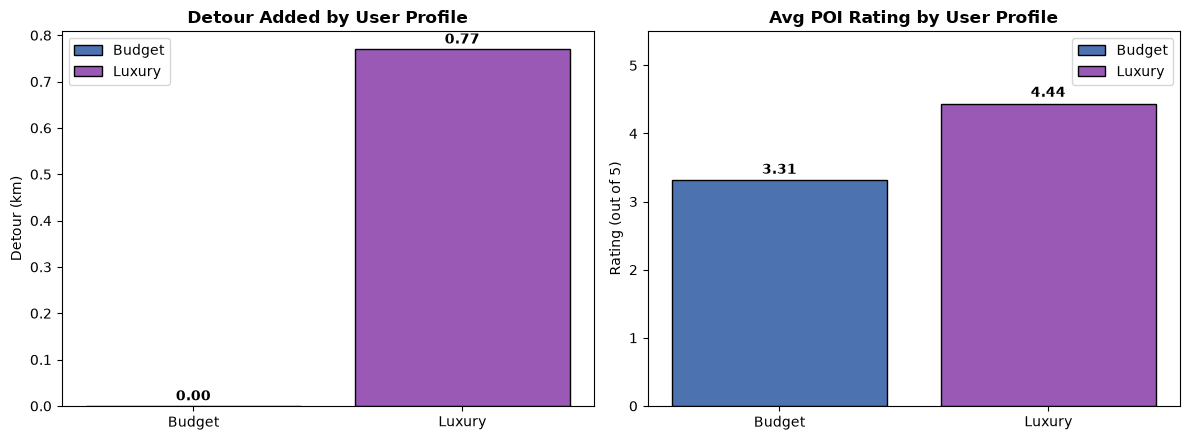

ML Personalisation Comparison
The Budget model selected POIs with an average rating of 3.31/5,
adding only 0.00 km of detour. The Luxury model accepted
0.77 km of extra travel to reach POIs rated 4.44/5.

This confirms that the Decision Tree models have learned meaningfully
different ranking behaviours from their training data: the Budget model
prioritises proximity and low detour, while the Luxury model trades travel
efficiency for higher-rated venues.


In [24]:
# ============================================================
# 11.1.1. ML personalisation \u2013 visual comparison
# ============================================================

# Extract Budget vs Luxury metrics from batch results for charting.
if len(batch_results_df) >= 2:
    ml_rows = batch_results_df[batch_results_df["Test Feature"].str.contains("ML Test")]
    if len(ml_rows) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        profiles = ml_rows["User Profile"].tolist()
        detours = ml_rows["Detour Added (km)"].tolist()
        ratings = ml_rows["Avg Rating"].tolist()
        profile_colors = ["#4C72B0", "#9B59B6"]

        bars = axes[0].bar(profiles, detours, color=profile_colors, edgecolor="black", label=profiles)
        axes[0].set_title("Detour Added by User Profile", fontweight="bold")
        axes[0].set_ylabel("Detour (km)")
        for bar, val in zip(bars, detours):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                         f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
        axes[0].legend()

        bars = axes[1].bar(profiles, ratings, color=profile_colors, edgecolor="black", label=profiles)
        axes[1].set_title("Avg POI Rating by User Profile", fontweight="bold")
        axes[1].set_ylabel("Rating (out of 5)")
        axes[1].set_ylim(0, 5.5)
        for bar, val in zip(bars, ratings):
            axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                         f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        # --- Interpretation ---
        print("ML Personalisation Comparison")
        print("=" * 55)
        print(f"The Budget model selected POIs with an average rating of {ratings[0]:.2f}/5,")
        print(f"adding only {detours[0]:.2f} km of detour. The Luxury model accepted")
        print(f"{detours[1]:.2f} km of extra travel to reach POIs rated {ratings[1]:.2f}/5.")
        print(f"\nThis confirms that the Decision Tree models have learned meaningfully")
        print(f"different ranking behaviours from their training data: the Budget model")
        print(f"prioritises proximity and low detour, while the Luxury model trades travel")
        print(f"efficiency for higher-rated venues.")

## 12. Analysis and Discussion

### Dijkstra vs A* — Search Efficiency
Both algorithms successfully found identical optimal routes. But, **A* expanded significantly fewer nodes**. By using a haversine-based heuristic, A* safely pruned the search space. This efficiency is critical because the system runs A* repeatedly to score up to 60 different candidate stops.

### Fixed Formula vs ML-Driven Scoring
Initially, POIs were scored using a rigid, hard-coded formula. Replacing this with a **Machine Learning Decision Tree** allowed the system to automatically adapt to different user profiles. The Budget model learned to prioritize distance, while the Luxury model prioritized high ratings. In a real-world scenario, this model would continually learn from live user feedback.

### TSP Scalability
The waypoint ordering currently uses exact permutation enumeration. While mathematically perfect for 3–4 stops, its $O(N!)$ complexity would crash on a 10+ stop itinerary. We optimized this significantly by introducing an $O(N^2)$ **Distance Matrix**, but a production system would still need approximate heuristics (like Genetic Algorithms) for massive itineraries.

### Limitations & Future Work
- **Static Graph:** OpenStreetMap data doesn't reflect real-time traffic jams.
- **Synthetic Training:** The ML models are currently trained on synthetic data.
- **Scalability:** The system downloads the full city network into memory, which isn't viable for global maps without chunking or contraction hierarchies.

## 13. Conclusion

This project developed for AI-based travel assistant that combines graph search algorithms, machine learning, knowledge representation, and optimization techniques into a single pipeline. The system is capable of generating personalized travel recommendations, finding efficient routes, and creating optimized itineraries based on user preferences.

**Key Points:**

1. **Route Planning:**  
   Implemented custom Dijkstra and A* search algorithms to calculate routes using real-world road network data obtained from OpenStreetMap. The system demonstrates how heuristic-based search can improve efficiency compared to uninformed search methods.

2. **Personalized Recommendations:**  
   Developed machine learning models that classify and recommend attractions based on different user profiles, such as Budget and Luxury preferences. The models successfully learned the important features affecting each profile's choices.

3. **Itinerary Optimization:**  
   Applied the Travelling Salesperson Problem (TSP) approach with a pre-computed distance matrix to determine an efficient order for visiting selected attractions.

4. **System Visualization and Evaluation:**  
   Generated interactive maps and test scenarios to evaluate the behaviour of the routing and recommendation components. These visualizations helped demonstrate the differences between search algorithms and the impact of user preferences on generated routes.

Overall, the project shows how multiple AI techniques can be combined to create a practical travel planning system. The modular design allows individual components such as routing, recommendation, and optimization to be improved independently as more data and advanced methods become available.

## 14. Limitations and Future Improvements

The current system has several limitations that provide opportunities for future improvements.

- The routing component depends on OpenStreetMap data, which may contain incomplete or outdated geographic information in some areas. Improving data quality or integrating additional map sources could improve route accuracy.

- The recommendation models were trained using synthetic data generated from predefined preference rules. While this allowed controlled evaluation, real user interaction data would provide more accurate predictions of traveller preferences.

- The attraction dataset is static and does not include real-time information such as opening hours, ticket availability, temporary closures, or events. Connecting the system with live tourism and location APIs would make recommendations more practical.

- The routing model uses static travel costs and does not consider live traffic conditions, weather, or unexpected road changes. Future versions could incorporate real-time data sources.

- The exact TSP approach becomes computationally expensive when the number of locations increases. For larger itineraries, approximation methods such as Genetic Algorithms or other meta-heuristic approaches could improve scalability.

- User preferences are currently represented using simplified profiles such as Budget and Luxury. A more advanced system could include additional factors such as travel purpose, accessibility needs, time constraints, and personal interests.